Final Converged Energies:
  1 rep: -1.13728382 Hartree
  2 rep: -1.13728381 Hartree
  3 rep: -1.13728383 Hartree
  4 rep: -1.13728382 Hartree
  5 rep: -1.13728383 Hartree

Total Iterations:
  1 rep: 56
  2 rep: 87
  3 rep: 117
  4 rep: 159
  5 rep: 146



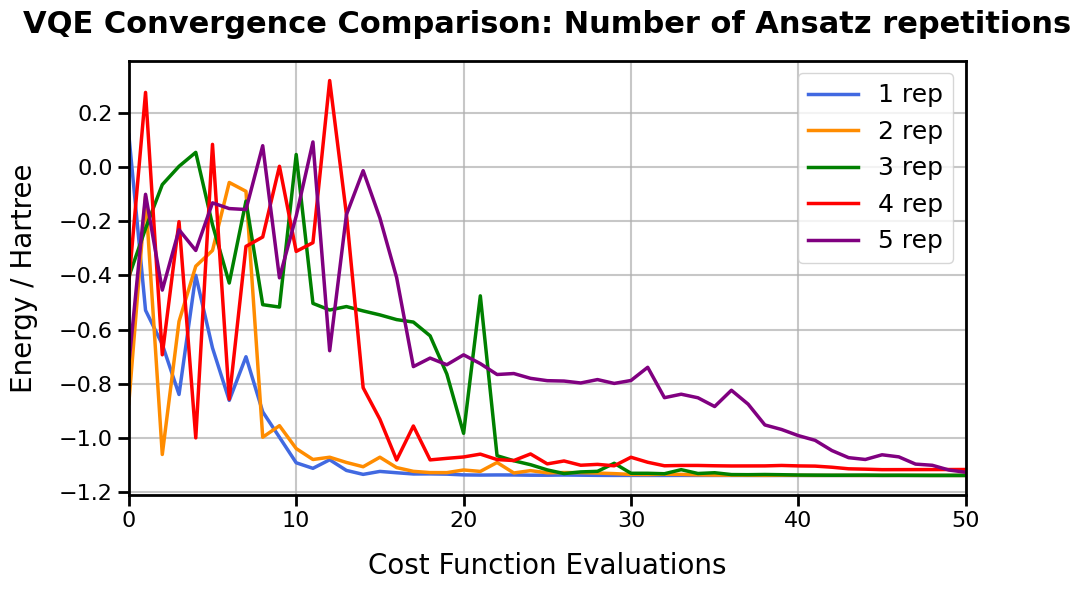

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the two convergence data files
with open('../data/vqe_conv_uccsd_jw_1.json', 'r') as f:
    data_1rep = json.load(f)

with open('../data/vqe_conv_uccsd_jw_2.json', 'r') as f:
    data_2rep = json.load(f)
    
with open('../data/vqe_conv_uccsd_jw_3.json', 'r') as f:
    data_3rep = json.load(f)
    
with open('../data/vqe_conv_uccsd_jw_4.json', 'r') as f:
    data_4rep = json.load(f)
    
with open('../data/vqe_conv_uccsd_jw_5.json', 'r') as f:
    data_5rep = json.load(f)

# Extract convergence data
conv_rep1 = data_1rep['convergence'][0]
conv_rep2 = data_2rep['convergence'][0]
conv_rep3 = data_3rep['convergence'][0]
conv_rep4 = data_4rep['convergence'][0]
conv_rep5 = data_5rep['convergence'][0]

# Print final converged energies
print("Final Converged Energies:")
print(f"  1 rep: {conv_rep1[-1]:.8f} Hartree")
print(f"  2 rep: {conv_rep2[-1]:.8f} Hartree")
print(f"  3 rep: {conv_rep3[-1]:.8f} Hartree")
print(f"  4 rep: {conv_rep4[-1]:.8f} Hartree")
print(f"  5 rep: {conv_rep5[-1]:.8f} Hartree")
print()

# Print number of iterations
print("Total Iterations:")
print(f"  1 rep: {len(conv_rep1)}")
print(f"  2 rep: {len(conv_rep2)}")
print(f"  3 rep: {len(conv_rep3)}")
print(f"  4 rep: {len(conv_rep4)}")
print(f"  5 rep: {len(conv_rep5)}")
print()

# Create the comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(conv_rep1, label='1 rep', linewidth=2.5, marker='o', markersize=0, markevery=5, color='royalblue')
ax.plot(conv_rep2, label='2 rep', linewidth=2.5, marker='s', markersize=0, markevery=5, color='darkorange')
ax.plot(conv_rep3, label='3 rep', linewidth=2.5, marker='^', markersize=0, markevery=5, color='green')
ax.plot(conv_rep4, label='4 rep', linewidth=2.5, marker='D', markersize=0, markevery=5, color='red')
ax.plot(conv_rep5, label='5 rep', linewidth=2.5, marker='v', markersize=0, markevery=5, color='purple')


ax.set_xlabel('Cost Function Evaluations', fontsize=20, labelpad=15)
ax.set_ylabel('Energy / Hartree', fontsize=20 , labelpad=15)
ax.set_title('VQE Convergence Comparison: Number of Ansatz repetitions', fontsize=22, fontweight='bold', pad=20)

ax.set_xlim(0, 50)

# Increase tick label size and tick length/thickness
ax.tick_params(axis='both', which='major', labelsize=16, length=8, width=2)

# Increase frame thickness
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.grid(True, alpha=0.7, linewidth=1.5)
ax.legend(fontsize=18, loc='best')
plt.tight_layout()

# plt.savefig('../images/presentation/repetition_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

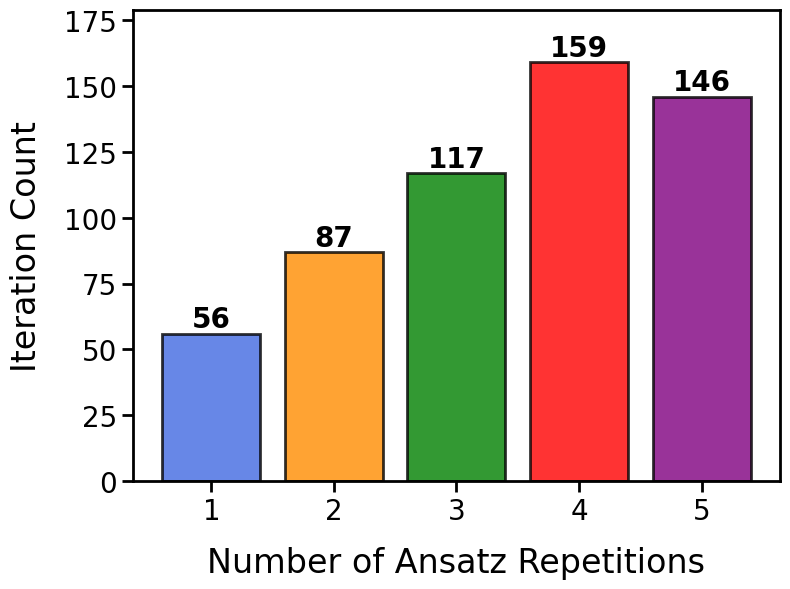

In [ ]:
# Create bar plot showing iterations vs number of repetitions
repetitions = [1, 2, 3, 4, 5]
iterations = [len(conv_rep1), len(conv_rep2), len(conv_rep3), len(conv_rep4), len(conv_rep5)]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(repetitions, iterations, color=['royalblue', 'darkorange', 'green', 'red', 'purple'], 
               alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on top of bars
for bar, val in zip(bars, iterations):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}',
            ha='center', va='bottom', fontsize=20, fontweight='bold')

ax.set_xlabel('Number of Ansatz Repetitions', fontsize=24, labelpad=15)
ax.set_ylabel('Iteration Count', fontsize=24, labelpad=15)
# ax.set_title('Convergence Speed: Iterations vs Ansatz Complexity', fontsize=23, fontweight='bold', pad=30)
ax.set_xticks(repetitions)

plt.ylim(0, max(iterations) + 20)

# Increase tick label size and tick length/thickness
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=2)

# Increase frame thickness
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

# plt.savefig('../images/presentation/iterations_vs_repetitions.png', dpi=300, bbox_inches='tight')
plt.show()
